In [1]:
# Martin MacDonald
# Honours Project
# 2D Discrete Traffic Model

In [2]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [3]:
####
#Setup the grid
####

In [4]:
#Setup grid.
rows = 30
columns = 30
total_size = rows * columns
grid = np.zeros((rows, columns), dtype=np.int16)

#Add randomly generated cars to test.
num_cars = 5

#Ensure there are not more cars than the total size of the grid, throw a value error if there are.
if num_cars > total_size:
    raise ValueError("There are too many cars for the size of the grid")

#Define the Car class, used to hold data about each car.
class Car:
    def __init__(self, car_id, position, goal):
        self.id = car_id
        self.position = position
        self.goal = goal

#Cars dictionary which holds each car, its ID, positon & goal.
cars = {}

#Generates a randomly positioned car, checks if that space is already occupied, if it is, try again, 
#if not, add car to grid & dictionary and give it a unique ID.
car_id = 1
while car_id <= num_cars:
    #Generate random position
    row = np.random.randint(0, rows)
    col = np.random.randint(0, columns)
    #Check if the car can spawn on unoccupied space.
    if grid[row, col] == 0:
        #If the space is clear, add that car to cars dictionary & grid and increment car_id by 1.
        grid[row, col] = car_id
        goal_row = np.random.randint(0, rows)
        goal_column = np.random.randint(0, columns)
        cars[car_id] = Car(car_id, (row, col), (goal_row, goal_column))
        car_id += 1

In [5]:
#Manhattan Distance
def manhattan_distance(x1, y1, x2, y2):
    return (abs(x1 - x2) + abs(y1 - y2))

In [10]:
#Get neighbours for a given position.
def get_neighbours(position, rows, columns):
    #Get the current cars position and split it into row and column.
    row, column = position
    #Setup a list to contain neighbours.
    neighbours = []

    #Create a list of tuples which represent each cardinal direction/possible move
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    #For each direction, get the new position when taking that direction into account. 
    #If that position would be off the side of the grid, don't append it to the neighbours list.
    for delta_row, delta_column in directions:
        new_row, new_column = row + delta_row, column + delta_column

        if 0 <= new_row < rows and 0 <= new_column < columns:
            neighbours.append((new_row, new_column))

    #Return all the valid neighbours of the current car. 
    return neighbours

In [ ]:
#Reconstruct the path from start to goal using came_from.
def reconstruct_path(came_from, start, goal):
    #Set the current position to goal.
    current = goal
    #Setup a list to contain the path.
    path = []

    #While current has not reached the start, add the current step to the path 
    #then set current to its parent step (the next step along on the way to start).
    while current != start:
        path.append(current)
        current = came_from[current]

    #Add the start to the path.
    path.append(start)
    #Reverse the path list so it can be followed as start -> goal, rather than goal -> start which it was.
    path.reverse()
    #Return the newly created path.
    return path

In [7]:
####
#Draw canvas
####

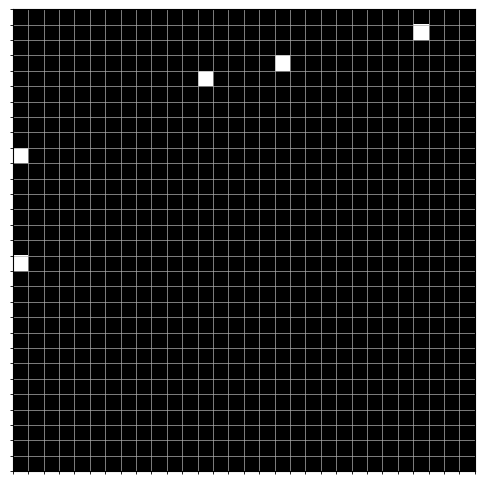

In [8]:
#Create the canvas for the grid.
plt.figure(figsize=(6, 6))
#Draw the grid.
plt.imshow(grid, cmap='gray', vmin=0, vmax=1, aspect='equal')

#Draw gridlines, makes it easier to see positions.
plt.gca().set_xticks(np.arange(-0.5, columns, 1), minor=True)
plt.gca().set_yticks(np.arange(-0.5, rows, 1), minor=True)
plt.grid(which='minor', linewidth=0.5)

# Remove labelling, disable this code to see them again.
plt.xticks([])
plt.yticks([])

#Display the grid.
plt.show()